# Inspect replay_structure data artifacts

This notebook discovers, loads, and inspects `.obj` artifacts under `replay_structure/data`.

It uses project-native loaders from `replay_structure.read_write` whenever possible and falls back to direct object loading for robust exploration.

In [1]:
from pathlib import Path
import re
from typing import Any, Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from replay_structure.metadata import DATA_PATH, HighSynchronyEvents, PlaceFieldID_Shuffle, Poisson, Ripples, Run_Snippets
from replay_structure.read_write import load_compressed_data, load_data, load_ratday_data, load_spikemat_data, load_structure_data

plt.rcParams["figure.figsize"] = (6, 4)
pd.set_option("display.max_colwidth", 120)

print(f"DATA_PATH: {DATA_PATH}")

DATA_PATH: H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data


In [2]:
OBJ_PATTERN = re.compile(r"^(?P<prefix>.+)_(?P<bin_size_cm>\d+)cm(?:_(?P<time_window_ms>\d+)ms(?:_(?P<likelihood>[A-Za-z0-9_]+))?)?$")

SPK_DATA_TYPE_BY_FOLDER = {
    "ripples": Ripples(),
    "run_snippets": Run_Snippets(),
    "high_synchrony_events": HighSynchronyEvents(),
    "placefieldID_shuffle": PlaceFieldID_Shuffle(),
}


def parse_obj_filename(path: Path) -> Dict[str, Any]:
    folder = path.parent.name
    stem = path.stem
    match = OBJ_PATTERN.match(stem)
    if match is None:
        return {"folder": folder, "session": None, "bin_size_cm": None, "time_window_ms": None, "likelihood": None, "data_type_token": None, "parse_ok": False}

    prefix = match.group("prefix")
    bin_size_cm = int(match.group("bin_size_cm"))
    time_window_ms = match.group("time_window_ms")
    likelihood = match.group("likelihood")
    session = prefix
    data_type_token = None

    if folder == "structure_analysis_input" and "_" in prefix:
        session, data_type_token = prefix.split("_", 1)

    return {
        "folder": folder,
        "session": session,
        "bin_size_cm": bin_size_cm,
        "time_window_ms": None if time_window_ms is None else int(time_window_ms),
        "likelihood": likelihood,
        "data_type_token": data_type_token,
        "parse_ok": True,
    }


def build_catalog(data_path: Path = DATA_PATH) -> pd.DataFrame:
    rows = []
    for path in sorted(data_path.glob("*/*.obj")):
        stat = path.stat()
        parsed = parse_obj_filename(path)
        rows.append({
            "folder": parsed["folder"],
            "filename": path.name,
            "path": str(path),
            "session": parsed["session"],
            "bin_size_cm": parsed["bin_size_cm"],
            "time_window_ms": parsed["time_window_ms"],
            "likelihood": parsed["likelihood"],
            "data_type_token": parsed["data_type_token"],
            "parse_ok": parsed["parse_ok"],
            "size_kb": round(stat.st_size / 1024.0, 2),
            "mtime": pd.Timestamp(stat.st_mtime, unit="s"),
        })

    catalog_df = pd.DataFrame(rows)
    if catalog_df.empty:
        return catalog_df

    return catalog_df.sort_values(["folder", "session", "filename"]).reset_index(drop=True)


catalog_df = build_catalog()
display(catalog_df)

,folder,filename,path,session,bin_size_cm,time_window_ms,likelihood,data_type_token,parse_ok,size_kb,mtime
0,high_synchrony_events,rat1day1_4cm_3ms.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\high_synchrony_events\...,rat1day1,4,3.0,None,None,True,948495.65,2026-04-14 23:58:44.840630531
1,placefieldID_shuffle,rat1day1_4cm_3ms.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\placefieldID_shuffle\r...,rat1day1,4,3.0,None,None,True,332588.28,2026-04-14 23:39:54.827290773
2,ratday,rat0day4_4cm.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\ratday\rat0day4_4cm.obj,rat0day4,4,NaN,None,None,True,565257.69,2026-04-14 21:30:20.791896343
3,ratday,rat1day1_4cm.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\ratday\rat1day1_4cm.obj,rat1day1,4,NaN,None,None,True,568927.45,2026-04-15 16:19:43.100675583
4,ratday,rat2day1_4cm.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\ratday\rat2day1_4cm.obj,rat2day1,4,NaN,None,None,True,346604.55,2026-04-24 15:11:29.502615452
5,ripples,rat1day1_4cm_3ms.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\ripples\rat1day1_4cm_3...,rat1day1,4,3.0,None,None,True,332573.96,2026-04-15 14:26:08.226943493
6,ripples,rat2day1_4cm_3ms.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\ripples\rat2day1_4cm_3...,rat2day1,4,3.0,None,None,True,282019.95,2026-04-15 17:49:01.209450483
7,run_snippets,rat1day1_4cm_60ms.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\run_snippets\rat1day1_...,rat1day1,4,60.0,None,None,True,94923.10,2026-04-14 23:57:23.467372656
8,structure_analysis_input,rat1day1_ripples_4cm_3ms_poisson.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\structure_analysis_inp...,rat1day1,4,3.0,poisson,ripples,True,160026.19,2026-04-15 14:26:09.407831192
9,structure_analysis_input,rat2day1_ripples_4cm_3ms_poisson.obj,H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\structure_analysis_inp...,rat2day1,4,3.0,poisson,ripples,True,132878.75,2026-04-15 17:49:02.023701191


In [3]:
def safe_load(path: str) -> Any:
    try:
        return load_data(path, print_filename=False)
    except Exception:
        return load_compressed_data(path, print_filename=False)


def try_typed_load(row: pd.Series) -> Any:
    folder = row["folder"]
    session = row["session"]
    bin_size_cm = int(row["bin_size_cm"]) if pd.notna(row["bin_size_cm"]) else 4
    time_window_ms = int(row["time_window_ms"]) if pd.notna(row["time_window_ms"]) else None

    if folder == "ratday":
        return load_ratday_data(session_indicator=session, bin_size_cm=bin_size_cm, ext="")

    if folder in SPK_DATA_TYPE_BY_FOLDER and time_window_ms is not None:
        return load_spikemat_data(session_indicator=session, time_window_ms=time_window_ms, data_type=SPK_DATA_TYPE_BY_FOLDER[folder], bin_size_cm=bin_size_cm, ext="", print_filename=False)

    if folder == "structure_analysis_input" and time_window_ms is not None:
        data_type_token = (row.get("data_type_token") or "ripples").lower()
        likelihood_token = (row.get("likelihood") or "poisson").lower()
        data_type_obj = {"ripples": Ripples(), "run_snippets": Run_Snippets(), "high_synchrony_events": HighSynchronyEvents(), "placefieldid_shuffle": PlaceFieldID_Shuffle()}.get(data_type_token)
        likelihood_obj = {"poisson": Poisson()}.get(likelihood_token)
        if data_type_obj is None:
            raise ValueError(f"Unsupported structure data_type_token: {data_type_token}")
        if likelihood_obj is None:
            raise ValueError(f"Unsupported likelihood token: {likelihood_token}")
        return load_structure_data(session_indicator=session, time_window_ms=time_window_ms, data_type=data_type_obj, likelihood_function=likelihood_obj, bin_size_cm=bin_size_cm, ext="", print_filename=False)

    return safe_load(row["path"])


def inspect_value(value: Any) -> str:
    if isinstance(value, np.ndarray):
        return f"ndarray{value.shape}"
    if isinstance(value, dict):
        return f"dict(len={len(value)})"
    if isinstance(value, (list, tuple, set)):
        return f"{type(value).__name__}(len={len(value)})"
    return type(value).__name__


def describe_object(obj: Any, max_attrs: int = 30, max_dict_keys: int = 8) -> pd.DataFrame:
    rows = []
    if hasattr(obj, "__dict__"):
        attrs = list(vars(obj).keys())
        for attr_name in attrs[:max_attrs]:
            attr_value = getattr(obj, attr_name)
            attr_summary = inspect_value(attr_value)
            dict_preview = None
            if isinstance(attr_value, dict):
                preview_items = list(attr_value.items())[:max_dict_keys]
                dict_preview = {str(k): inspect_value(v) for k, v in preview_items}
            rows.append({"attr": attr_name, "summary": attr_summary, "dict_preview": dict_preview})
    else:
        rows.append({"attr": "(no __dict__)", "summary": type(obj).__name__, "dict_preview": None})

    summary_df = pd.DataFrame(rows)
    print(f"type: {type(obj)}")
    return summary_df

In [4]:
loaded_raw: Dict[str, Any] = {}
loaded_typed: Dict[str, Optional[Any]] = {}
typed_errors: Dict[str, str] = {}

for _, row in catalog_df.iterrows():
    path = row["path"]
    loaded_raw[path] = safe_load(path)
    try:
        loaded_typed[path] = try_typed_load(row)
        typed_errors[path] = ""
    except Exception as exc:
        loaded_typed[path] = None
        typed_errors[path] = str(exc)

catalog_df["cls_name"] = catalog_df["path"].map(lambda p: type(loaded_raw[p]).__name__)
catalog_df["typed_loaded"] = catalog_df["path"].map(lambda p: loaded_typed[p] is not None)
catalog_df["typed_error"] = catalog_df["path"].map(lambda p: typed_errors[p])
catalog_df["repr_short"] = catalog_df["path"].map(lambda p: repr(loaded_raw[p])[:90])

display(catalog_df[["folder", "filename", "session", "bin_size_cm", "time_window_ms", "likelihood", "cls_name", "typed_loaded", "size_kb"]])

typed_failures_df = catalog_df.loc[~catalog_df["typed_loaded"], ["folder", "filename", "typed_error"]]
if len(typed_failures_df) > 0:
    print("Typed loader failures (raw load still succeeded):")
    display(typed_failures_df)

loading  H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\ratday\rat0day4_4cm.obj
loading  H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\ratday\rat1day1_4cm.obj
loading  H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\ratday\rat2day1_4cm.obj


,folder,filename,session,bin_size_cm,time_window_ms,likelihood,cls_name,typed_loaded,size_kb
0,high_synchrony_events,rat1day1_4cm_3ms.obj,rat1day1,4,3.0,None,HighSynchronyEvents_Preprocessing,True,948495.65
1,placefieldID_shuffle,rat1day1_4cm_3ms.obj,rat1day1,4,3.0,None,Ripple_Preprocessing,True,332588.28
2,ratday,rat0day4_4cm.obj,rat0day4,4,NaN,None,RatDay_Preprocessing,True,565257.69
3,ratday,rat1day1_4cm.obj,rat1day1,4,NaN,None,RatDay_Preprocessing,True,568927.45
4,ratday,rat2day1_4cm.obj,rat2day1,4,NaN,None,RatDay_Preprocessing,True,346604.55
5,ripples,rat1day1_4cm_3ms.obj,rat1day1,4,3.0,None,Ripple_Preprocessing,True,332573.96
6,ripples,rat2day1_4cm_3ms.obj,rat2day1,4,3.0,None,Ripple_Preprocessing,True,282019.95
7,run_snippets,rat1day1_4cm_60ms.obj,rat1day1,4,60.0,None,Run_Snippet_Preprocessing,True,94923.10
8,structure_analysis_input,rat1day1_ripples_4cm_3ms_poisson.obj,rat1day1,4,3.0,poisson,Structure_Analysis_Input,True,160026.19
9,structure_analysis_input,rat2day1_ripples_4cm_3ms_poisson.obj,rat2day1,4,3.0,poisson,Structure_Analysis_Input,True,132878.75


In [5]:
def first_matrix_from_mapping(mapping: Any) -> Optional[np.ndarray]:
    if not isinstance(mapping, dict) or len(mapping) == 0:
        return None
    for _, value in mapping.items():
        if isinstance(value, np.ndarray):
            return value
    return None


def show_heatmap(matrix: Optional[np.ndarray], title: str, cmap: str = "viridis") -> None:
    if matrix is None:
        print(f"No matrix available for: {title}")
        return
    plt.figure()
    plt.imshow(matrix, aspect="auto", cmap=cmap)
    plt.title(title)
    plt.colorbar()
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()

## ratday


### rat0day4_4cm.obj
type: <class 'replay_structure.ratday_preprocessing.RatDay_Preprocessing'>


,attr,summary,dict_preview
0,params,RatDay_Preprocessing_Parameters,None
1,raw_data,dict(len=13),"{'significant_ripples': 'ndarray(5624,)', 'ripple_info': 'ndarray(5624, 2)', 'inhibitory_neurons': 'ndarray(0,)', 'e..."
2,data,dict(len=14),"{'significant_ripples': 'ndarray(5624,)', 'ripple_info': 'ndarray(5624, 2)', 'inhibitory_neurons': 'ndarray(0,)', 'e..."
3,velocity_info,dict(len=4),"{'vel_times_s': 'ndarray(3118373,)', 'vel_cm_per_s': 'ndarray(3118373,)', 'run_starts': 'ndarray(17794,)', 'run_ends..."
4,place_field_data,dict(len=12),"{'run_data': 'dict(len=3)', 'spatial_grid': 'dict(len=2)', 'position_histogram': 'ndarray(50, 50)', 'spike_histogram..."


data keys: ['excitatory_neurons', 'inhibitory_neurons', 'large_position_gaps_inds', 'n_cells', 'n_ripples', 'pos_times_s', 'pos_xy_cm', 'ripple_info', 'ripple_times_s', 'significant_ripples', 'spike_ids', 'spike_times_s']
n_ripples: 5624
n_place_cells: 94


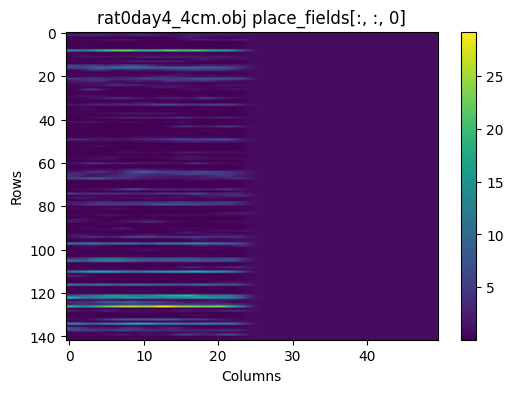


### rat1day1_4cm.obj
type: <class 'replay_structure.ratday_preprocessing.RatDay_Preprocessing'>


,attr,summary,dict_preview
0,params,RatDay_Preprocessing_Parameters,None
1,raw_data,dict(len=13),"{'significant_ripples': 'ndarray(5624,)', 'ripple_info': 'ndarray(5624, 2)', 'inhibitory_neurons': 'ndarray(0,)', 'e..."
2,data,dict(len=14),"{'significant_ripples': 'ndarray(5624,)', 'ripple_info': 'ndarray(5624, 2)', 'inhibitory_neurons': 'ndarray(0,)', 'e..."
3,velocity_info,dict(len=4),"{'vel_times_s': 'ndarray(3118373,)', 'vel_cm_per_s': 'ndarray(3118373,)', 'run_starts': 'ndarray(17794,)', 'run_ends..."
4,place_field_data,dict(len=12),"{'run_data': 'dict(len=3)', 'spatial_grid': 'dict(len=2)', 'position_histogram': 'ndarray(60, 60)', 'spike_histogram..."


data keys: ['excitatory_neurons', 'inhibitory_neurons', 'large_position_gaps_inds', 'n_cells', 'n_ripples', 'pos_times_s', 'pos_xy_cm', 'ripple_info', 'ripple_times_s', 'significant_ripples', 'spike_ids', 'spike_times_s']
n_ripples: 5624
n_place_cells: 104


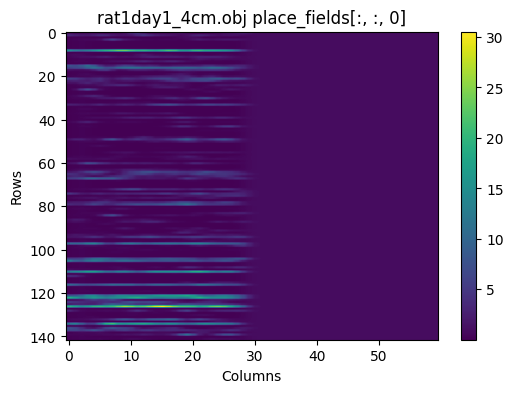


### rat2day1_4cm.obj
type: <class 'replay_structure.ratday_preprocessing.RatDay_Preprocessing'>


,attr,summary,dict_preview
0,params,RatDay_Preprocessing_Parameters,None
1,raw_data,dict(len=13),"{'significant_ripples': 'ndarray(10160,)', 'ripple_info': 'ndarray(10160, 2)', 'inhibitory_neurons': 'ndarray(0,)', ..."
2,data,dict(len=14),"{'significant_ripples': 'ndarray(10160,)', 'ripple_info': 'ndarray(10160, 2)', 'inhibitory_neurons': 'ndarray(0,)', ..."
3,velocity_info,dict(len=4),"{'vel_times_s': 'ndarray(3609183,)', 'vel_cm_per_s': 'ndarray(3609183,)', 'run_starts': 'ndarray(12436,)', 'run_ends..."
4,place_field_data,dict(len=12),"{'run_data': 'dict(len=3)', 'spatial_grid': 'dict(len=2)', 'position_histogram': 'ndarray(60, 60)', 'spike_histogram..."


data keys: ['excitatory_neurons', 'inhibitory_neurons', 'large_position_gaps_inds', 'n_cells', 'n_ripples', 'pos_times_s', 'pos_xy_cm', 'ripple_info', 'ripple_times_s', 'significant_ripples', 'spike_ids', 'spike_times_s']
n_ripples: 10160
n_place_cells: 39


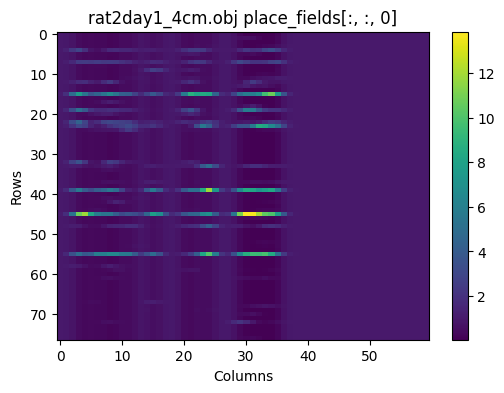

In [6]:
ratday_rows = catalog_df[catalog_df["folder"] == "ratday"]
for _, row in ratday_rows.iterrows():
    obj = loaded_typed[row["path"]] if loaded_typed[row["path"]] is not None else loaded_raw[row["path"]]
    print(f"\n### {row['filename']}")
    display(describe_object(obj))
    if hasattr(obj, "data") and isinstance(obj.data, dict):
        print(f"data keys: {sorted(obj.data.keys())[:12]}")
        print(f"n_ripples: {obj.data.get('n_ripples')}")
    if hasattr(obj, "place_field_data") and isinstance(obj.place_field_data, dict):
        print(f"n_place_cells: {obj.place_field_data.get('n_place_cells')}")
        place_fields = obj.place_field_data.get("place_fields")
        if isinstance(place_fields, np.ndarray):
            if place_fields.ndim == 3:
                show_heatmap(place_fields[:, :, 0], title=f"{row['filename']} place_fields[:, :, 0]")
            elif place_fields.ndim == 2:
                show_heatmap(place_fields, title=f"{row['filename']} place_fields")

## ripples and placefieldID_shuffle


### placefieldID_shuffle / rat1day1_4cm_3ms.obj
type: <class 'replay_structure.ripple_preprocessing.Ripple_Preprocessing'>


,attr,summary,dict_preview
0,params,Ripple_Preprocessing_Parameters,None
1,data,dict(len=3),"{'ripple_times_s': 'ndarray(5624, 2)', 'n_ripples': 'int', 'n_place_cells': 'int'}"
2,pf_matrix,"ndarray(94, 2500)",None
3,ripple_info,dict(len=7),"{'spikemats_fullripple': 'dict(len=5624)', 'spikemats_popburst': 'dict(len=5624)', 'popburst_times_s': 'ndarray(5624..."


ripple_info keys: ['avg_spikes_per_s_smoothed', 'firing_rate_scaling', 'popburst_mean_firing_rate_array', 'popburst_mean_firing_rate_matrix', 'popburst_times_s', 'spikemats_fullripple', 'spikemats_popburst']


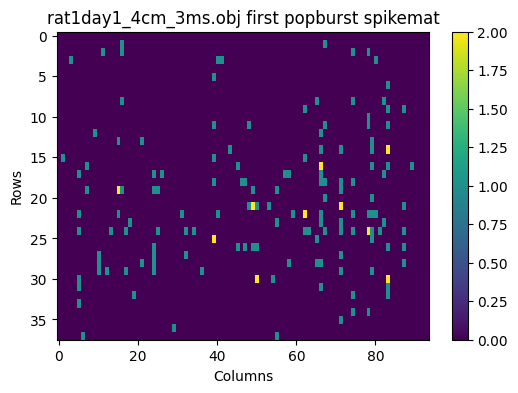

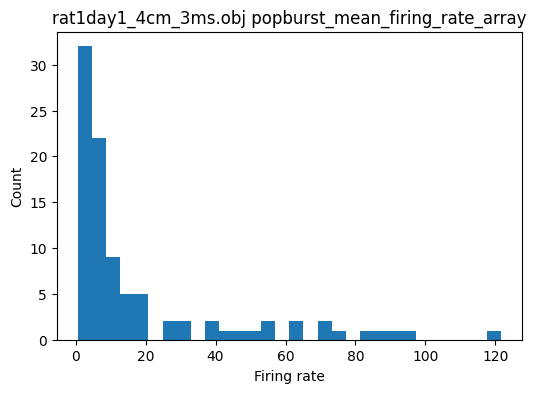


### ripples / rat1day1_4cm_3ms.obj
type: <class 'replay_structure.ripple_preprocessing.Ripple_Preprocessing'>


,attr,summary,dict_preview
0,params,Ripple_Preprocessing_Parameters,None
1,data,dict(len=3),"{'ripple_times_s': 'ndarray(5624, 2)', 'n_ripples': 'int', 'n_place_cells': 'int'}"
2,pf_matrix,"ndarray(94, 2500)",None
3,ripple_info,dict(len=7),"{'spikemats_fullripple': 'dict(len=5624)', 'spikemats_popburst': 'dict(len=5624)', 'popburst_times_s': 'ndarray(5624..."


ripple_info keys: ['avg_spikes_per_s_smoothed', 'firing_rate_scaling', 'popburst_mean_firing_rate_array', 'popburst_mean_firing_rate_matrix', 'popburst_times_s', 'spikemats_fullripple', 'spikemats_popburst']


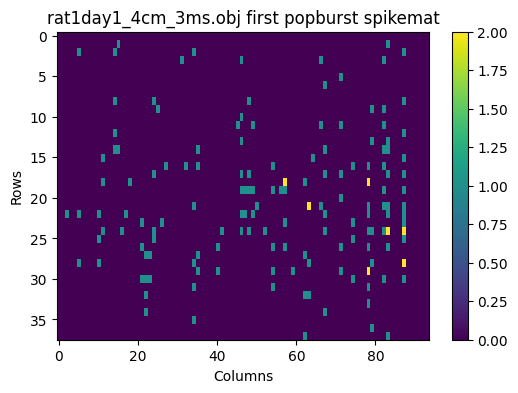

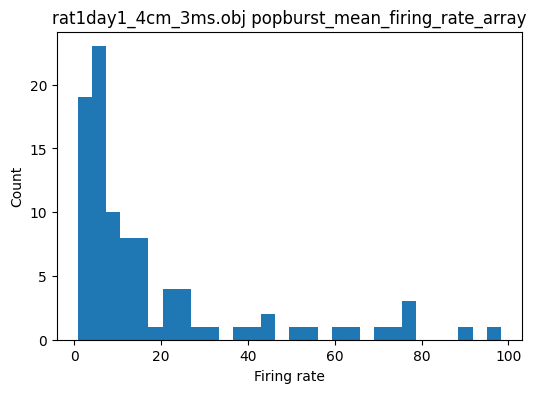


### ripples / rat2day1_4cm_3ms.obj
type: <class 'replay_structure.ripple_preprocessing.Ripple_Preprocessing'>


,attr,summary,dict_preview
0,params,Ripple_Preprocessing_Parameters,None
1,data,dict(len=3),"{'ripple_times_s': 'ndarray(10160, 2)', 'n_ripples': 'int', 'n_place_cells': 'int'}"
2,pf_matrix,"ndarray(39, 3600)",None
3,ripple_info,dict(len=7),"{'spikemats_fullripple': 'dict(len=10160)', 'spikemats_popburst': 'dict(len=10160)', 'popburst_times_s': 'ndarray(10..."


ripple_info keys: ['avg_spikes_per_s_smoothed', 'firing_rate_scaling', 'popburst_mean_firing_rate_array', 'popburst_mean_firing_rate_matrix', 'popburst_times_s', 'spikemats_fullripple', 'spikemats_popburst']


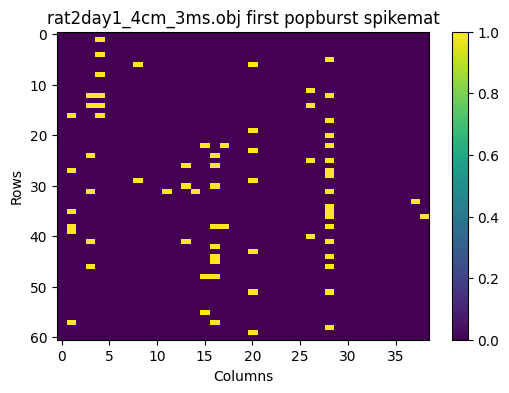

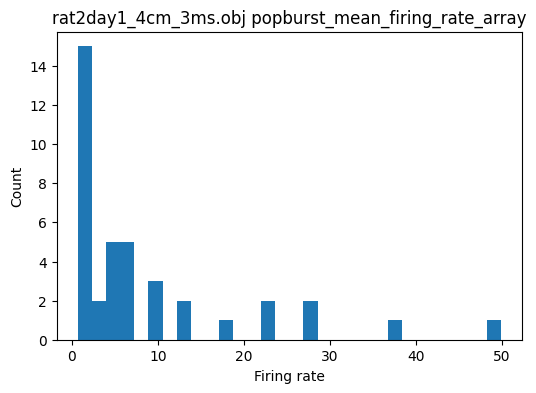

In [7]:
ripple_like_folders = ["ripples", "placefieldID_shuffle"]
ripple_like_rows = catalog_df[catalog_df["folder"].isin(ripple_like_folders)]
for _, row in ripple_like_rows.iterrows():
    obj = loaded_typed[row["path"]] if loaded_typed[row["path"]] is not None else loaded_raw[row["path"]]
    print(f"\n### {row['folder']} / {row['filename']}")
    display(describe_object(obj))

    ripple_info = getattr(obj, "ripple_info", None)
    if isinstance(ripple_info, dict):
        print(f"ripple_info keys: {sorted(ripple_info.keys())}")
        first_popburst = first_matrix_from_mapping(ripple_info.get("spikemats_popburst"))
        show_heatmap(first_popburst, title=f"{row['filename']} first popburst spikemat")
        fr_array = ripple_info.get("popburst_mean_firing_rate_array")
        if isinstance(fr_array, np.ndarray) and fr_array.size > 0:
            plt.figure()
            plt.hist(fr_array, bins=30)
            plt.title(f"{row['filename']} popburst_mean_firing_rate_array")
            plt.xlabel("Firing rate")
            plt.ylabel("Count")
            plt.show()

## run_snippets


### rat1day1_4cm_60ms.obj
type: <class 'replay_structure.run_snippet_preprocessing.Run_Snippet_Preprocessing'>


,attr,summary,dict_preview
0,params,Run_Snippet_Preprocessing_Parameters,None
1,pf_matrix,"ndarray(94, 2500)",None
2,run_info,dict(len=3),"{'run_times_s': 'ndarray(3823, 2)', 'true_trajectories_cm': 'dict(len=3823)', 'spikemats': 'dict(len=3823)'}"


run_info keys: ['run_times_s', 'spikemats', 'true_trajectories_cm']


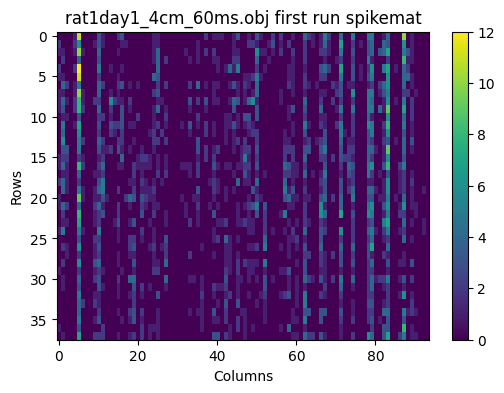

In [8]:
run_rows = catalog_df[catalog_df["folder"] == "run_snippets"]
for _, row in run_rows.iterrows():
    obj = loaded_typed[row["path"]] if loaded_typed[row["path"]] is not None else loaded_raw[row["path"]]
    print(f"\n### {row['filename']}")
    display(describe_object(obj))

    run_info = getattr(obj, "run_info", None)
    if isinstance(run_info, dict):
        print(f"run_info keys: {sorted(run_info.keys())}")
        first_spikemat = first_matrix_from_mapping(run_info.get("spikemats"))
        show_heatmap(first_spikemat, title=f"{row['filename']} first run spikemat")

## high_synchrony_events


### rat1day1_4cm_3ms.obj
type: <class 'replay_structure.highsynchronyevents.HighSynchronyEvents_Preprocessing'>


,attr,summary,dict_preview
0,params,HighSynchronyEvents_Preprocessing_Parameters,None
1,pf_matrix,"ndarray(94, 2500)",None
2,highsynchronyevent_info,dict(len=7),"{'spike_hist': 'ndarray(25986458,)', 'spike_hist_smoothed': 'ndarray(25986458,)', 'spike_hist_times_s': 'ndarray(259..."
3,spikemat_info,dict(len=6),"{'spikemats_full': 'dict(len=8096)', 'spikemats_popburst': 'dict(len=8096)', 'popburst_times_s': 'ndarray(8096, 2)',..."


spikemat_info keys: ['avg_spikes_per_s_smoothed', 'firing_rate_scaling', 'popburst_mean_firing_rate_array', 'popburst_times_s', 'spikemats_full', 'spikemats_popburst']


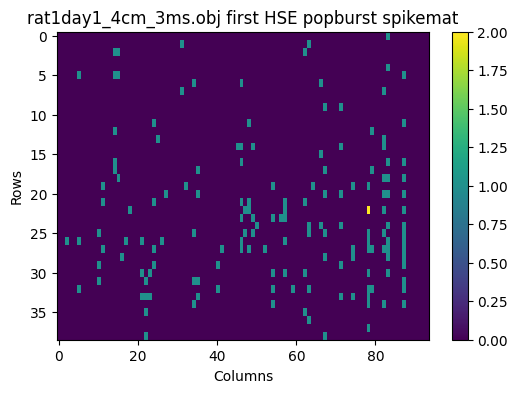

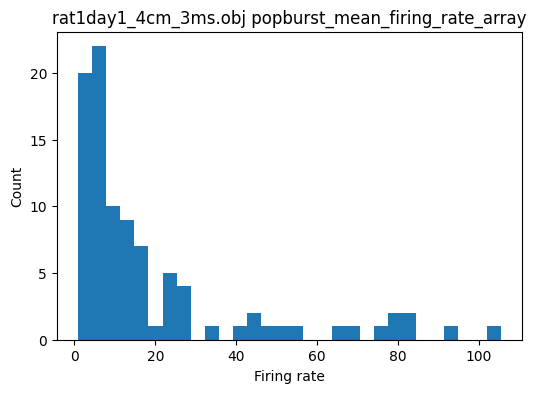

In [9]:
hse_rows = catalog_df[catalog_df["folder"] == "high_synchrony_events"]
for _, row in hse_rows.iterrows():
    obj = loaded_typed[row["path"]] if loaded_typed[row["path"]] is not None else loaded_raw[row["path"]]
    print(f"\n### {row['filename']}")
    display(describe_object(obj))

    spikemat_info = getattr(obj, "spikemat_info", None)
    if isinstance(spikemat_info, dict):
        print(f"spikemat_info keys: {sorted(spikemat_info.keys())}")
        first_popburst = first_matrix_from_mapping(spikemat_info.get("spikemats_popburst"))
        show_heatmap(first_popburst, title=f"{row['filename']} first HSE popburst spikemat")
        fr_array = spikemat_info.get("popburst_mean_firing_rate_array")
        if isinstance(fr_array, np.ndarray) and fr_array.size > 0:
            plt.figure()
            plt.hist(fr_array, bins=30)
            plt.title(f"{row['filename']} popburst_mean_firing_rate_array")
            plt.xlabel("Firing rate")
            plt.ylabel("Count")
            plt.show()

## structure_analysis_input


### rat1day1_ripples_4cm_3ms_poisson.obj
type: <class 'replay_structure.structure_analysis_input.Structure_Analysis_Input'>


,attr,summary,dict_preview
0,pf_matrix,"ndarray(94, 2500)",None
1,spikemats,dict(len=5624),"{'0': 'NoneType', '1': 'ndarray(38, 94)', '2': 'ndarray(82, 94)', '3': 'ndarray(76, 94)', '4': 'ndarray(112, 94)', '..."
2,source_metadata,dict(len=0),{}
3,params,Structure_Analysis_Input_Parameters,None


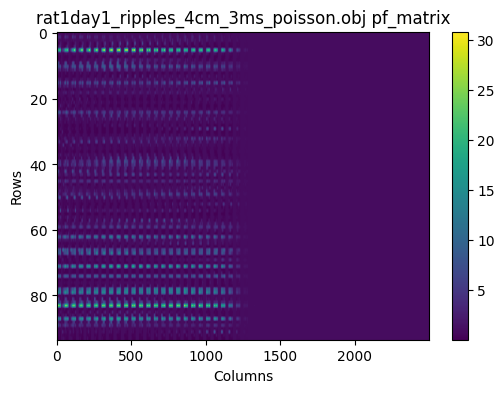

n_spikemats: 5624


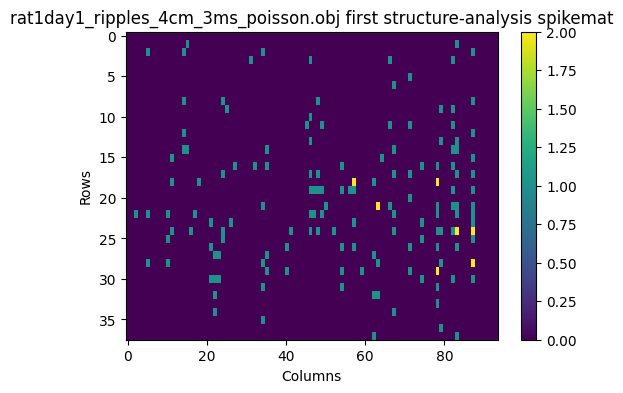

params: <replay_structure.config.Structure_Analysis_Input_Parameters object at 0x000001C578ADEA90>

### rat2day1_ripples_4cm_3ms_poisson.obj
type: <class 'replay_structure.structure_analysis_input.Structure_Analysis_Input'>


,attr,summary,dict_preview
0,pf_matrix,"ndarray(39, 3600)",None
1,spikemats,dict(len=10160),"{'0': 'ndarray(61, 39)', '1': 'ndarray(44, 39)', '2': 'ndarray(70, 39)', '3': 'ndarray(134, 39)', '4': 'ndarray(143,..."
2,source_metadata,dict(len=0),{}
3,params,Structure_Analysis_Input_Parameters,None


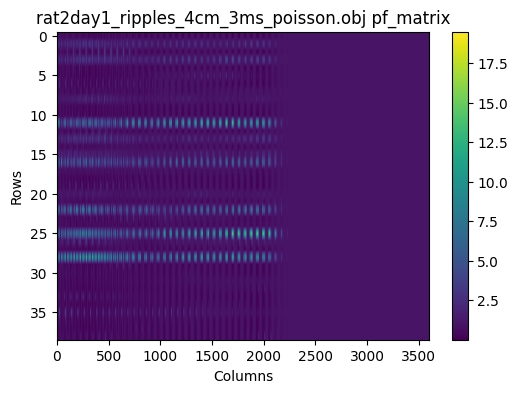

n_spikemats: 10160


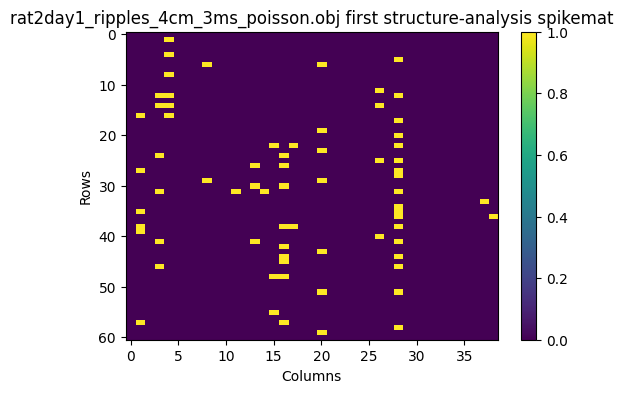

params: <replay_structure.config.Structure_Analysis_Input_Parameters object at 0x000001C6070A5C40>


In [10]:
sai_rows = catalog_df[catalog_df["folder"] == "structure_analysis_input"]
for _, row in sai_rows.iterrows():
    obj = loaded_typed[row["path"]] if loaded_typed[row["path"]] is not None else loaded_raw[row["path"]]
    print(f"\n### {row['filename']}")
    display(describe_object(obj))

    pf_matrix = getattr(obj, "pf_matrix", None)
    if isinstance(pf_matrix, np.ndarray):
        if pf_matrix.ndim == 2:
            show_heatmap(pf_matrix, title=f"{row['filename']} pf_matrix")
        elif pf_matrix.ndim == 3:
            show_heatmap(pf_matrix[:, :, 0], title=f"{row['filename']} pf_matrix[:, :, 0]")

    spikemats = getattr(obj, "spikemats", None)
    if isinstance(spikemats, dict):
        print(f"n_spikemats: {len(spikemats)}")
        first_spikemat = first_matrix_from_mapping(spikemats)
        show_heatmap(first_spikemat, title=f"{row['filename']} first structure-analysis spikemat")
    elif isinstance(spikemats, (list, tuple)):
        print(f"n_spikemats: {len(spikemats)}")
        first_spikemat = spikemats[0] if len(spikemats) > 0 and isinstance(spikemats[0], np.ndarray) else None
        show_heatmap(first_spikemat, title=f"{row['filename']} first structure-analysis spikemat")

    print(f"params: {getattr(obj, 'params', None)}")

## final artifact summary

In [11]:
def compact_object_size(obj: Any) -> str:
    if isinstance(obj, np.ndarray):
        return f"ndarray{obj.shape}"
    if isinstance(obj, dict):
        return f"dict(len={len(obj)})"
    if isinstance(obj, (list, tuple)):
        return f"{type(obj).__name__}(len={len(obj)})"
    return type(obj).__name__


def key_attrs(obj: Any) -> str:
    if hasattr(obj, "__dict__"):
        return ", ".join(list(vars(obj).keys())[:6])
    return ""


summary_rows = []
for _, row in catalog_df.iterrows():
    obj = loaded_raw[row["path"]]
    n_items_or_shape = ""
    if hasattr(obj, "spikemats"):
        spikemats = getattr(obj, "spikemats")
        if isinstance(spikemats, dict):
            n_items_or_shape = f"spikemats={len(spikemats)}"
        elif isinstance(spikemats, (list, tuple)):
            n_items_or_shape = f"spikemats={len(spikemats)}"
    elif hasattr(obj, "ripple_info") and isinstance(getattr(obj, "ripple_info"), dict):
        rip = getattr(obj, "ripple_info")
        n_items_or_shape = f"spikemats_popburst={len(rip.get('spikemats_popburst', {}))}"
    elif hasattr(obj, "run_info") and isinstance(getattr(obj, "run_info"), dict):
        run_info = getattr(obj, "run_info")
        n_items_or_shape = f"spikemats={len(run_info.get('spikemats', {}))}"
    elif hasattr(obj, "spikemat_info") and isinstance(getattr(obj, "spikemat_info"), dict):
        sm_info = getattr(obj, "spikemat_info")
        n_items_or_shape = f"spikemats_popburst={len(sm_info.get('spikemats_popburst', {}))}"
    else:
        n_items_or_shape = compact_object_size(obj)

    summary_rows.append({
        "folder": row["folder"],
        "filename": row["filename"],
        "class": type(obj).__name__,
        "n_items_or_shape": n_items_or_shape,
        "key_attrs": key_attrs(obj),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["folder", "filename"]).reset_index(drop=True)
display(summary_df)

,folder,filename,class,n_items_or_shape,key_attrs
0,high_synchrony_events,rat1day1_4cm_3ms.obj,HighSynchronyEvents_Preprocessing,spikemats_popburst=8096,"params, pf_matrix, highsynchronyevent_info, spikemat_info"
1,placefieldID_shuffle,rat1day1_4cm_3ms.obj,Ripple_Preprocessing,spikemats_popburst=5624,"params, data, pf_matrix, ripple_info"
2,ratday,rat0day4_4cm.obj,RatDay_Preprocessing,RatDay_Preprocessing,"params, raw_data, data, velocity_info, place_field_data"
3,ratday,rat1day1_4cm.obj,RatDay_Preprocessing,RatDay_Preprocessing,"params, raw_data, data, velocity_info, place_field_data"
4,ratday,rat2day1_4cm.obj,RatDay_Preprocessing,RatDay_Preprocessing,"params, raw_data, data, velocity_info, place_field_data"
5,ripples,rat1day1_4cm_3ms.obj,Ripple_Preprocessing,spikemats_popburst=5624,"params, data, pf_matrix, ripple_info"
6,ripples,rat2day1_4cm_3ms.obj,Ripple_Preprocessing,spikemats_popburst=10160,"params, data, pf_matrix, ripple_info"
7,run_snippets,rat1day1_4cm_60ms.obj,Run_Snippet_Preprocessing,spikemats=3823,"params, pf_matrix, run_info"
8,structure_analysis_input,rat1day1_ripples_4cm_3ms_poisson.obj,Structure_Analysis_Input,spikemats=5624,"pf_matrix, spikemats, source_metadata, params"
9,structure_analysis_input,rat2day1_ripples_4cm_3ms_poisson.obj,Structure_Analysis_Input,spikemats=10160,"pf_matrix, spikemats, source_metadata, params"


# Reference: contents of `.obj` artifact files

Despite the `.obj` extension, these files are **plain Python pickles** (not Wavefront 3D meshes). They are written by [`save_data`](../replay_structure/read_write.py) (`pickle.dumps`) and read back by [`load_data`](../replay_structure/read_write.py) (`pickle.loads`). Compressed variants exist via [`save_compressed_data`](../replay_structure/read_write.py) but are not used for files under `replay_structure/data/`.

Folder names mirror the string forms of [`Data_Type`](../replay_structure/metadata.py): `ratday`, `ripples`, `run_snippets`, `high_synchrony_events`, `placefieldID_shuffle`, `placefield_rotation`, `poisson_simulated_ripples`, `negbinomial_simulated_ripples`, `ripples_pf`, `high_synchrony_events_pf`, plus the cross-cutting `structure_analysis_input` / `spikemat_structure_analysis_input` directories. Notebooks shipped with the publication often refer to `data_final` / `results_final`; the contents are the same as what this codebase writes to `data/` and `results/`.

## Data artifacts (`replay_structure/data/`)

| Path pattern | Pickled Python type | Contents |
| --- | --- | --- |
| `ratday/{session}_{bin}cm.obj` (optionally `_placefields_rotated`) | [`RatDay_Preprocessing`](../replay_structure/ratday_preprocessing.py) | Session-level preprocessing of the original Pfeiffer & Foster MATLAB export. Attributes: `params` ([`RatDay_Preprocessing_Parameters`](../replay_structure/config.py)), cleaned behavior/spikes in `data` (positions, spike times/IDs, ripple times, well info), `velocity_info` (run starts/ends), `place_field_data` (place fields, place-cell IDs, mean firing rates). |
| `ripples/{session}_{bin}cm_{ms}ms.obj`, `placefieldID_shuffle/...`, `placefield_rotation/...`, `ripples_pf/...` | [`Ripple_Preprocessing`](../replay_structure/ripple_preprocessing.py) | Per-SWR neural activity. Attributes: `params` ([`Ripple_Preprocessing_Parameters`](../replay_structure/config.py)), `pf_matrix` (cells x bins place-field matrix), `data` (slim ratday view), `ripple_info` dict with `spikemats_fullripple`, `spikemats_popburst`, `popburst_times_s`, `avg_spikes_per_s_smoothed`, `popburst_mean_firing_rate_array/_matrix`, and `firing_rate_scaling` (Gamma `alpha`/`beta` for the Negative-Binomial likelihood). The `placefieldID_shuffle` variant is identical except spike-IDs are shuffled before binning. |
| `run_snippets/{session}_{bin}cm_{ms}ms.obj` | [`Run_Snippet_Preprocessing`](../replay_structure/run_snippet_preprocessing.py) | Run-period control snippets length-matched to SWRs. Attributes: `params`, `pf_matrix`, `run_info` dict (`run_times_s`, `true_trajectories_cm`, `spikemats`). |
| `high_synchrony_events/{session}_{bin}cm_{ms}ms.obj`, `high_synchrony_events_pf/...` | [`HighSynchronyEvents_Preprocessing`](../replay_structure/highsynchronyevents.py) | HSEs detected from the smoothed population spike histogram. Attributes: `params`, `pf_matrix`, `highsynchronyevent_info` (spike histogram, threshold, `hse_times_s`), and `spikemat_info` (parallel structure to `ripple_info`: `spikemats_full`, `spikemats_popburst`, `popburst_times_s`, `firing_rate_scaling`, ...). |
| `poisson_simulated_ripples/{simulated_session}_{bin}cm_{ms}ms.obj`, `negbinomial_simulated_ripples/...` | [`Simulated_Data_Preprocessing`](../replay_structure/simulated_neural_data.py) | Synthetic spikes generated from a `Model_Recovery_Trajectory_Set`. Attributes: `params` ([`Simulated_Spikes_Parameters`](../replay_structure/simulated_neural_data.py)), `trajectory_set`, `trajectory_spikes`, `generative_fr`, and binned `spikemats`. |
| `poisson_simulated_ripples/{model}_simulated_trajectories.obj` | [`Model_Recovery_Trajectory_Set`](../replay_structure/model_recovery.py) | Set of [`Simulated_Trajectory`](../replay_structure/simulated_trajectories.py) instances drawn from a model-parameter prior, used to seed the simulated spikes above. |
| `structure_analysis_input/{session}_{data_type}_{bin}cm_{ms}ms_{likelihood}.obj` | [`Structure_Analysis_Input`](../replay_structure/structure_analysis_input.py) | Unified, model-ready inputs. Attributes: `pf_matrix`, `spikemats` (dict keyed by spikemat index, `None` for empty events), `params` ([`Structure_Analysis_Input_Parameters`](../replay_structure/config.py)), `source_metadata`. Built via the various `Structure_Analysis_Input.reformat_*` classmethods. |
| `spikemat_structure_analysis_input/...` | [`Structure_Analysis_Input`](../replay_structure/structure_analysis_input.py) | Same class, but emitted when the session indicator is a per-spikemat name ([`SessionSpikemat_Name`](../replay_structure/metadata.py)) rather than a session-level one. |

## Results artifacts (`replay_structure/results/{data_type}/`)

Filenames are always prefixed by `{session_indicator}_{bin_size_cm}cm_{time_window_ms}ms_` (and usually a `{likelihood_function}` token, e.g. `poisson` or `negbinomial`). The remaining suffix identifies the artifact class.

| Filename suffix | Pickled Python type | Contents |
| --- | --- | --- |
| `_{model}.obj` (e.g. `_diffusion`, `_momentum`, `_stationary`, `_stationary_gaussian`, `_random`) via [`save_structure_model_results`](../replay_structure/read_write.py) | `np.ndarray` | One log model evidence per spikemat for a single dynamics model evaluated at fixed (default) parameters. |
| `_{model}_gridsearch.obj` (and `_spikemat{k}_..._momentum_gridsearch.obj` for the per-spikemat momentum sweep) | [`Structure_Gridsearch`](../replay_structure/structure_models_gridsearch.py) subclass (`Stationary_Gaussian`, `Diffusion`, or `Momentum`) | Two attributes: `gridsearch_params` (the swept parameter grids, e.g. `sd_array_meters`, `decay_array`) and `gridsearch_results` (log-evidence array of shape `[n_spikemats, n_sd]` or `[n_spikemats, n_sd, n_decay]`). The momentum case is sharded per-spikemat and re-aggregated by [`aggregate_momentum_gridsearch`](../replay_structure/read_write.py). |
| `_{model}_gridsearch_marginalization.obj` | [`Gridsearch_Marginalization`](../replay_structure/model_comparison.py) | Marginalization of `gridsearch_results` over a fitted hyperprior. Attributes: `gridsearch_params`, `gridsearch_results`, `marginalization_info` (best-fit params, fitted prior densities) and `marginalized_model_evidences`. |
| `_{likelihood}_model_comparison.obj` | [`Model_Comparison`](../replay_structure/model_comparison.py) | Per-spikemat comparison across the five dynamics models. Attributes: `results_dataframe` (per-model log-evidences plus `mll_model` winner column), `max_ll_counts`, and `random_effects_results` (`gibbs`, `alpha_m`, `p_models`, `p_exceedance`). |
| `_factorial_model_comparison.obj` | [`Factorial_Model_Comparison`](../replay_structure/model_comparison.py) | Joint dynamics x emission (Poisson vs Negative-Binomial) factorial comparison. Same attribute shape as `Model_Comparison` but with a 5x2 model space. |
| `_{likelihood}_deviance_explained.obj` | [`Deviance_Explained`](../replay_structure/deviance_models.py) | Deviance-explained per spikemat per dynamics model relative to a saturated and a null-across-neurons model. Attributes: `saturated_model`, `null_model`, `results` (DataFrame, columns indexed by model name). |
| `_{likelihood}_trajectories.obj` (some legacy filenames carry an extra `_{N}` suffix, e.g. `..._poisson_trajectories_74.obj`) | [`Most_Likely_Trajectories`](../replay_structure/structure_trajectory.py) | Viterbi-decoded MAP trajectories under the diffusion model. Attributes: `params`, `sd_meters`, `sd_bins`, `viterbi_input`, `most_likely_trajectories` (dict keyed by spikemat index, each an array of grid positions). |
| `_spikemat{k}_{likelihood}_marginals.obj` | [`All_Models_Marginals`](../replay_structure/marginals.py) | Per-timestep latent posteriors for one spikemat under each dynamics model. Attributes: `params` (model parameter settings used) and `marginals` dict with keys `diffusion`, `momentum`, `stationary`, `stationary_gaussian`, `random`. |
| `_{likelihood}_diffusion_marginals.obj` | `dict` | Diffusion-model marginal outputs aggregated across spikemats; written by [`save_diffusion_marginals`](../replay_structure/read_write.py). |
| `_{likelihood}_{trajectory_type}_trajectories_diffusion_constant.obj` (optional `_binned_` variant) | [`Diffusion_Constant`](../replay_structure/diffusion_constant.py) | Stella et al. (2019) style diffusion-constant analysis of decoded paths. Attributes: `bin_size_cm`, `n_time_windows`, `diffusion_constant_info` (distance-by-time fit), `alpha`, `bootstrap_alpha_dist`. |
| `pf_analysis_{decoding_type}.obj` (full pattern `{session}_{bin}cm_{ms}ms_pf_analysis_{decoding_type}.obj`) | [`PF_Analysis`](../replay_structure/pf_analysis.py) | Place-field-only decoding baseline. Attributes: `decoding_type` (`map` or `mean`), thresholds (`min_adjacent_distance`, `min_steps_in_trajectory`, `min_trajectory_distance`), and a nested `results` structure with decoded positions and trajectory statistics. |
| `predictive_analysis_{bin}cm_{ms}ms_{likelihood}_{trajectory_type}trajectories.obj` | `tuple` | `(behavior_paths, angular_distances)` produced by [`run_predictive_analysis`](../replay_structure/pipelines/modeling_pipeline.py); compares decoded SWR trajectories to behavioral past/future paths. |

### Notes

- The list above covers the artifact types written by [`replay_structure/read_write.py`](../replay_structure/read_write.py); see that file for the canonical filename helpers.
- This documentation is derived from the Python source rather than from introspecting pickled bytes, so it captures the intended schema and is robust to artifacts that may not exist locally.